# Module 5: Reproducibility

#### Christian Adcock

#### A note on the Environment

For this project, I created a Conda environment with the required versions of Python and each library. The intention behind this is to reproduce the results of the original paper as accurately as possible.

### Objective: Reproduce the results of the original LSTM model. This includes reproducing visuals in the paper and reaching similar figures for the MAE, MSE, RMSE, and MAPE 

## Section 1: Import Libraries

In [10]:
# Code Block 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import random

%matplotlib inline
pd.set_option('display.max_columns', 500)
plt.style.use('fivethirtyeight')

## Section 2: Set Up and Import Data

For this section, I want to set the results of the paper, set a random seed, and load the data set.

In [15]:
# Code Block 2

paper_results = {
    "MAE": 5.89,
    "MSE": 52.14,
    "RMSE": 7.22,
    "MAPE": 2.65
}

In [17]:
# Code Block 3

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

In [19]:
# Code Block 4

ticker = "GOOG"
goog = yf.download(ticker, start = "2024-04-01", end = "2025-04-24")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2024-04-01,155.225601,155.721530,150.415089,150.593631,24469800
2024-04-02,154.600708,154.719741,152.210345,153.489833,17598100
2024-04-03,155.096649,155.275191,152.876882,153.658460,17266200
2024-04-04,150.702728,154.908192,150.643219,153.817158,24184800
2024-04-05,152.686478,153.579143,149.850750,150.444871,16297300


In [21]:
# Code Block 5

goog.columns = [col[0] for col in goog.columns]
goog.to_csv("../data/goog.csv")
goog.head()

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,155.225601,155.721530,150.415089,150.593631,24469800
2024-04-02,154.600708,154.719741,152.210345,153.489833,17598100
2024-04-03,155.096649,155.275191,152.876882,153.658460,17266200
2024-04-04,150.702728,154.908192,150.643219,153.817158,24184800
2024-04-05,152.686478,153.579143,149.850750,150.444871,16297300


In [23]:
# Code Block 6

df_goog = pd.read_csv("../data/goog.csv", parse_dates = ["Date"])
df_goog = df_goog.set_index("Date") 

Now the stock data has been loaded, and the goals are set. I will begin to reproduce the visual results of the paper.

## Section 3: Reproduce Visualizations

In this section, I will attempt to reproduce the Closing Price, Daily Moving Averages, and Daily Returns graphs as well as the Daily Return histogram.

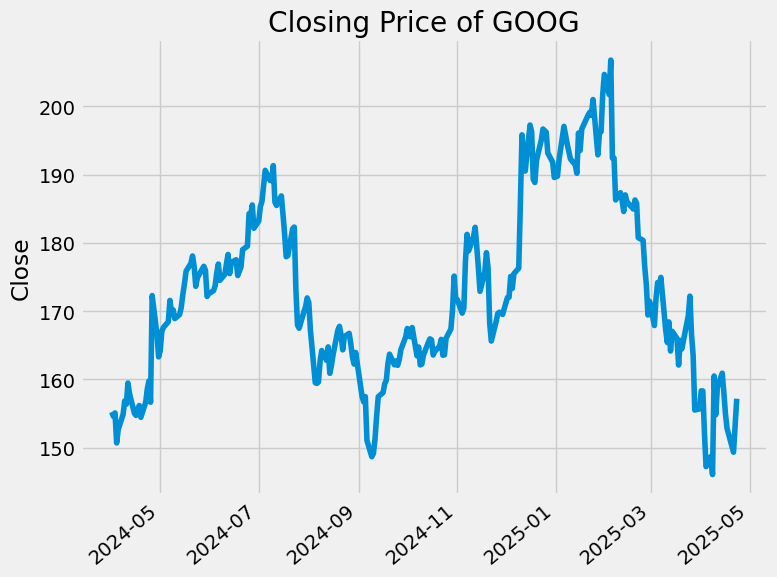

In [29]:
# Code Block 7

plt.figure(figsize = (8, 6))
plt.plot(df_goog.index, df_goog["Close"])
plt.title("Closing Price of GOOG")
plt.ylabel("Close")
plt.xticks(rotation = 40, ha = 'right')
plt.tight_layout()
plt.show()

In [31]:
# Code Block 8

df_goog["MA10"] = df_goog["Close"].rolling(window = 10).mean()
df_goog["MA20"] = df_goog["Close"].rolling(window = 20).mean()
df_goog["MA50"] = df_goog["Close"].rolling(window = 50).mean()

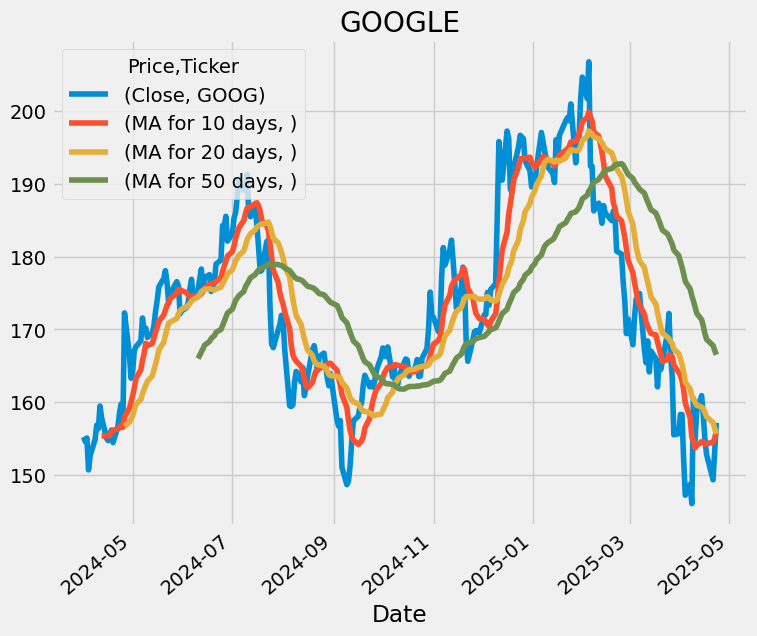

In [33]:
# Code Block 9

plt.figure(figsize = (8, 6))
plt.plot(df_goog.index, df_goog["Close"], label = "(Close, GOOG)")
plt.plot(df_goog.index, df_goog["MA10"], label = "(MA for 10 days, )")
plt.plot(df_goog.index, df_goog["MA20"], label = "(MA for 20 days, )")
plt.plot(df_goog.index, df_goog["MA50"], label = "(MA for 50 days, )")
plt.title("GOOGLE")
plt.xlabel("Date")
plt.xticks(rotation = 40, ha = 'right')
plt.legend(title = "Price,Ticker")

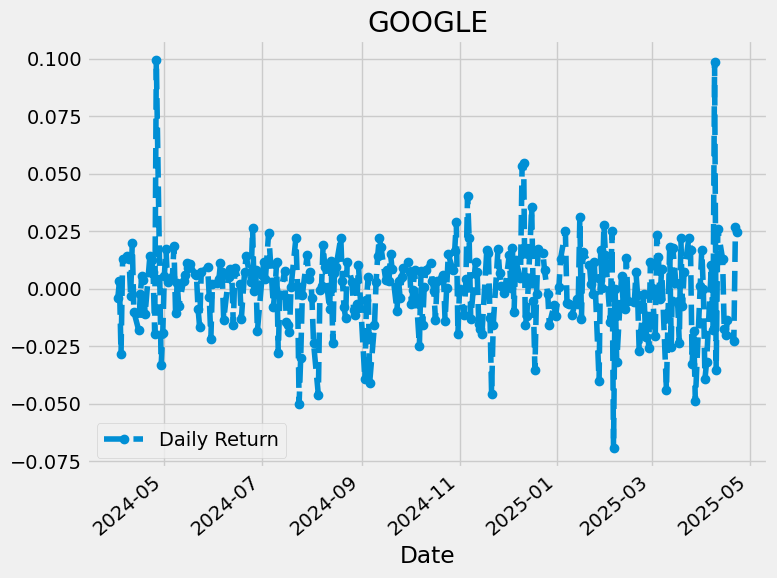

In [37]:
# Code Block 10

df_goog["Daily Return"] = df_goog["Close"].pct_change()

plt.figure(figsize = (8, 6))
plt.plot(df_goog.index, df_goog["Daily Return"], label = "Daily Return", linestyle = "--", marker = "o")
plt.title("GOOGLE")
plt.xlabel("Date")
plt.xticks(rotation = 40, ha = 'right')
plt.legend()
plt.tight_layout()
plt.show()

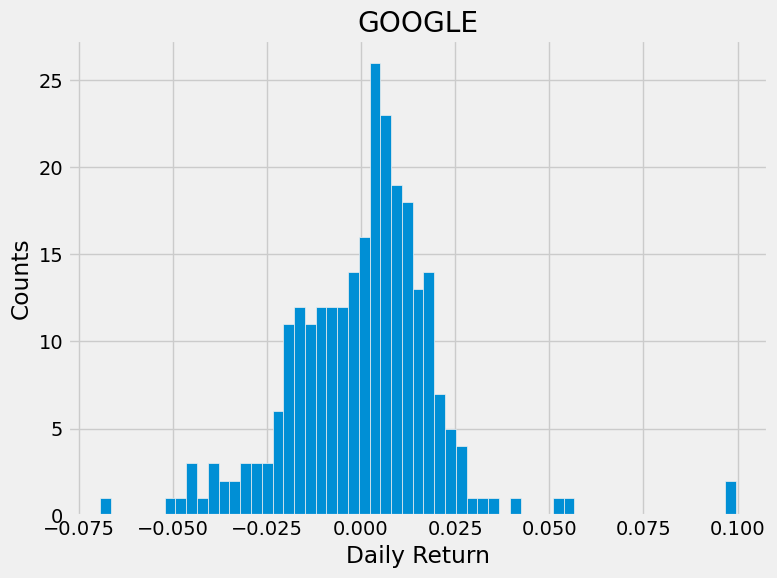

In [39]:
# Code Block 11

plt.figure(figsize = (8, 6))
sns.histplot(df_goog["Daily Return"].dropna(), bins = 59, alpha = 1)
plt.title("GOOGLE")
plt.xlabel("Daily Return")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

## Section 4: Reproduce the Model

For this section, I will reproduce the model as it was designed in the code appendix of the paper.

In [47]:
# Code Block 12

closing_prices = df_goog['Close'].values.reshape(-1, 1)

In [52]:
# Code Block 13

analyzer = SentimentIntensityAnalyzer()
news_data = ["Sample news article text"]
sentiments = [analyzer.polarity_scores(text)['compound'] for text in news_data]
sentiments = np.array(sentiments).reshape(-1, 1)
sentiments = np.repeat(sentiments, len(closing_prices)).reshape(-1, 1)


print(f"Closing prices shape is {closing_prices.shape}")
print(f"Sentiments shape is {sentiments.shape}")
print(f"Sentiment score used for all days is {sentiments[0][0]}")

Closing prices shape is (267, 1)
Sentiments shape is (267, 1)
Sentiment score used for all days is 0.0


In [54]:
# Code Block 14

scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(closing_prices)
scaled_sentiments = scaler.fit_transform(sentiments)

window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_prices)):
    X.append(np.column_stack((
    scaled_prices[i - window_size:i, 0],
    scaled_sentiments[i - window_size:i, 0]
    )))
    y.append(scaled_prices[i, 0])
X, y = np.array(X), np.array(y)

In [56]:
# Code Block 15

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [58]:
# Code Block 16

model = Sequential()
model.add(LSTM(64, return_sequences = True, input_shape = (window_size, 2)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1)) 
model.compile(optimizer = 'adam', loss = 'mse')

model.fit(X_train, y_train, epochs = 100, batch_size = 32, verbose = 1)

2026-03-31 23:55:32.684395: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-31 23:55:32.684746: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-31 23:55:32.685204: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-31 23:55:32.685288: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-31 23:55:32.685707: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefe

Epoch 1/100


2026-03-31 23:55:35.146522: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - loss: 0.1605
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0264
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0224
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0196
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0153
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0158
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0139
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0137
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0127
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0132
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0129
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0116
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0116
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0118
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0123
Epoch 16/100
6/6 ━━━━━━━━━━━━━

In [69]:
# Code Block 17

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


## Section 5: Evaluate the Model

In [71]:
# Code Block 18

mae = np.mean(np.abs(predictions - y_test_actual))
mse = np.mean((predictions - y_test_actual) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MAE: 0.0832
MSE: 0.0097
RMSE: 0.0985
MAPE: inf%


/var/folders/v0/c8l961l94ljf4c6jltfcp5l80000gn/T/ipykernel_47327/1152101444.py:6: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100


In [73]:
# Code Block 19

comparison_df = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "MAPE"],
        "Paper Google": [5.89, 52.14, 7.22, 2.65],
        "My Google": [mae, mse, rmse, mape]
    }
)

comparison_df["Difference"] = comparison_df["My Google"] - comparison_df["Paper Google"]
display(comparison_df)

,Metric,Paper Google,My Google,Difference
0,MAE,5.89,0.083165,-5.806835
1,MSE,52.14,0.009693,-52.130307
2,RMSE,7.22,0.098455,-7.121545
3,MAPE,2.65,inf,inf
